# 01 — Demand Patterns

**Business question:** Is arrival volume predictable enough to staff against? Specifically: does
demand show a strong day-of-week or hour-of-day pattern that scheduling should follow?


## Methodology

Arrivals are counted from `fct_er_visit`, joined to `dim_date` (day of week) and `dim_time_of_day`
(hour, shift, and the data-driven `is_peak` flag). Variability is summarized with the coefficient of
variation (CV = standard deviation / mean) of daily arrival counts -- a scale-free measure of how
"lumpy" demand is, which is what actually matters for staffing decisions (a CV near 0 means near-flat
demand; a CV well above ~0.3-0.4 would suggest real peaks and troughs worth staffing around).


In [1]:
import sys
from pathlib import Path

# Make the shared erops package importable when the kernel's cwd is notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
import plotly.express as px
import plotly.io as pio

# Static PNG output so every chart renders identically in Jupyter, VS Code,
# nbviewer and GitHub's notebook preview -- no JS runtime required to view it.
pio.renderers.default = "png"
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

from erops import metrics

con = metrics.get_connection()
print(f"Connected to {metrics.WAREHOUSE}")


Connected to C:\Users\dhwan\OneDrive\Desktop\PROJECTS\er-throughput-analytics\data\er.duckdb


### Arrivals by day of week


In [2]:
weekday = metrics.demand_by_weekday(con).sort_values("day_of_week_num")
weekday


,day_of_week_num,day_name,arrivals,avg_per_day
0,0,Sunday,1318,15.879518
1,1,Monday,1314,15.831325
2,2,Tuesday,1305,15.722892
3,3,Wednesday,1260,15.180723
4,4,Thursday,1332,16.243902
5,5,Friday,1310,15.975610
6,6,Saturday,1377,16.590361


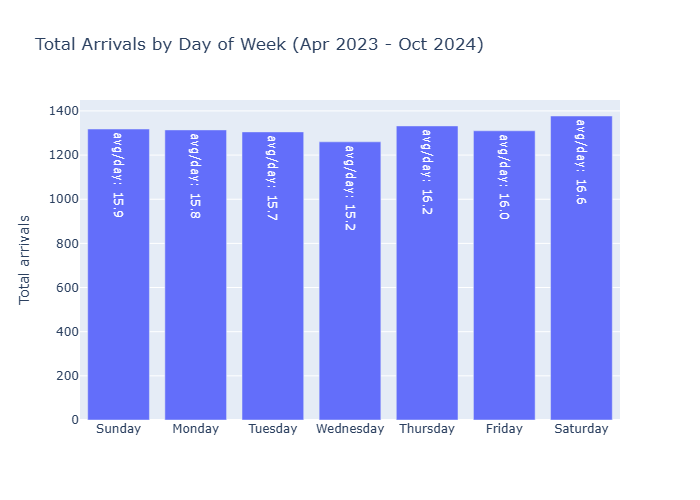

In [3]:
fig = px.bar(weekday, x="day_name", y="arrivals", text="avg_per_day",
             title="Total Arrivals by Day of Week (Apr 2023 - Oct 2024)")
fig.update_traces(texttemplate="avg/day: %{text:.1f}")
fig.update_layout(xaxis_title="", yaxis_title="Total arrivals")
fig.show()


Arrivals range from 1,260 (Wednesday) to 1,377 (Saturday) -- a spread of about 9% around the mean, with
no single day standing out sharply. There is a mild weekend uptick (see the weekend-vs-weekday
comparison below) but nothing resembling a strong weekly cycle.

> **Business decision this supports:** a uniform weekly staffing roster (same headcount every day) is
> defensible from this data; day-of-week-specific overstaffing or understaffing is not supported here.


### Arrivals by hour of day


In [4]:
hourly = metrics.demand_by_hour(con)
hourly


,hour_of_day,shift,is_peak,arrivals
0,0,Night,True,406
1,1,Night,False,372
2,2,Night,False,376
3,3,Night,True,385
4,4,Night,True,384
5,5,Night,True,393
6,6,Night,False,375
7,7,Day,True,415
8,8,Day,True,386
9,9,Day,True,388


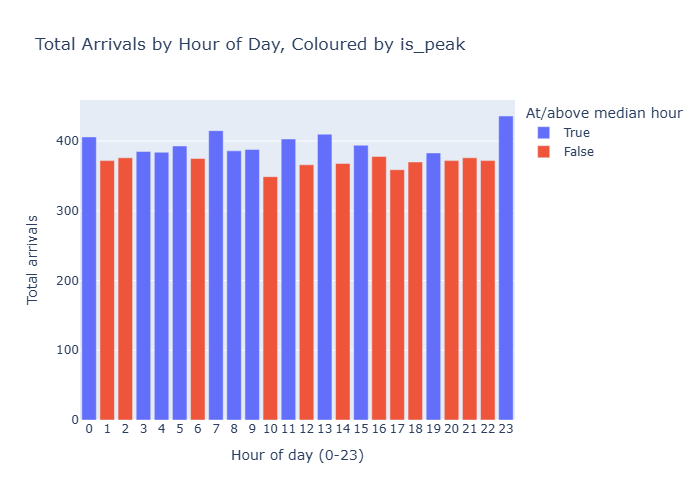

In [5]:
fig = px.bar(hourly, x="hour_of_day", y="arrivals", color="is_peak",
             title="Total Arrivals by Hour of Day, Coloured by is_peak",
             labels={"is_peak": "At/above median hour"})
fig.update_layout(xaxis={"dtick": 1}, xaxis_title="Hour of day (0-23)", yaxis_title="Total arrivals")
fig.show()


Hourly totals range narrowly, with no pronounced overnight lull or daytime surge of the kind typically
seen in real emergency departments (which usually show a clear afternoon/evening peak and an early-morning
trough). `is_peak` (defined in `dim_time_of_day` as at-or-above the median hour's arrival volume) is
scattered across the day rather than clustered in a contiguous "busy block".

> **Business decision this supports:** hour-by-hour shift-level overstaffing during a specific window is
> not supported by this data; if real-world demand is confirmed to look like this, shift staffing should
> be flat across the day rather than front- or back-loaded.


### Day-of-week x hour-of-day heatmap


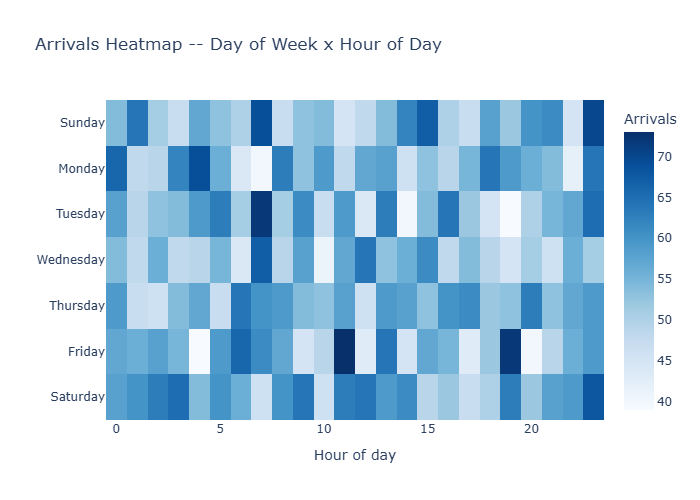

In [6]:
heat = metrics.demand_heatmap(con)
order = heat.drop_duplicates("day_of_week_num").sort_values("day_of_week_num")["day_name"].tolist()
pivot = heat.pivot(index="day_name", columns="hour_of_day", values="arrivals").reindex(order)
fig = px.imshow(pivot, color_continuous_scale="Blues", aspect="auto",
                 labels={"color": "Arrivals"}, title="Arrivals Heatmap -- Day of Week x Hour of Day")
fig.update_layout(xaxis_title="Hour of day", yaxis_title="")
fig.show()


No cell in this heatmap stands out as a hot spot -- the shading is close to uniform, confirming visually
what the marginal day-of-week and hour-of-day charts show separately: this dataset has essentially no
interaction effect between day and hour either.

> **Business decision this supports:** there is no specific day x hour combination (e.g. "Friday
> evenings") that this data says needs extra coverage.


### Variability summary


In [7]:
stats = metrics.demand_volume_stats(con)
print(f"Mean daily arrivals: {stats['mean_daily']:.2f}")
print(f"Std dev daily arrivals: {stats['sd_daily']:.2f}")
print(f"Coefficient of variation: {stats['cv_daily']:.3f}")
print(f"Weekday average: {stats['weekday_avg']:.2f}  |  Weekend average: {stats['weekend_avg']:.2f}"
      f"  ({(stats['weekend_avg']/stats['weekday_avg'] - 1):+.1%} vs weekday)")


Mean daily arrivals: 15.92
Std dev daily arrivals: 3.73
Coefficient of variation: 0.234
Weekday average: 15.79  |  Weekend average: 16.23  (+2.8% vs weekday)


A coefficient of variation of ~0.23 on daily arrivals is low -- daily volume typically stays within
roughly a fifth of the mean in either direction. The weekend is about 3% busier than weekdays, a
difference too small to justify a distinct weekend staffing model on its own.


## Executive Summary

Demand for this emergency department is close to flat: daily arrival volume has a coefficient of
variation of only 0.23, weekday and weekend averages differ by roughly 3%, and hourly arrival totals
show no pronounced diurnal peak or trough. Observed waits do **not** show the strong day-of-week /
time-of-day structure typically expected of a real ED, which is unusual and is treated as a data
characteristic to flag rather than a genuine operational insight to act on without corroboration.

## Business Recommendations

- If this pattern is confirmed against real scheduling and census data, a flat staffing roster
  (constant headcount by day and by hour) is a reasonable starting point -- there is no evidence here
  to justify concentrating staff in a particular time window.
- Before making a staffing change on the strength of this finding alone, corroborate it against actual
  shift logs or a longer real-world data pull, given the provenance caveat below.
- Do not use this notebook's hour-of-day breakdown to justify shift differentials; the data does not
  support one.

## Limitations

- **Provenance caveat:** real EDs almost always show a diurnal and weekly demand cycle (afternoon/evening
  peak, weekend elevation). Its near-total absence here is consistent with `docs/limitations.md`'s note
  that this dataset's origin is unverified and it may be synthetic or partially synthetic -- this finding
  should be corroborated, not acted on directly, before it drives a real staffing decision.
- Single facility, no comparator (`docs/limitations.md`).
- No seasonality decomposition was performed; only 19 months are observed, likely too short to separate
  a seasonal effect from a trend even if one existed.

## Next Steps

`02_wait_distribution.ipynb` characterizes the wait-time distribution itself, independent of when
patients arrive.
